# Kreditriskmodell — Svenska Bolån
**Syfte:** Bygga och validera en logistisk regressionsmodell för att prediktera default(=betalnings)-risk på bolån. Analysen följer ett strukturerat arbetsflöde från datainläsning till modellvalidering, i linje med krav under IFRS 9.

IFRS 9 är en internationell redovisningsstandard som banker måste följa. Den kräver att banker beräknar och reserverar pengar för förväntade kreditförluster — alltså lån som riskerar att inte betalas tillbaka.
För min modell betyder det:

Dokumentationskrav - Varje variabel i modellen måste motiveras — varför är den med, vad mäter den, är den statistiskt signifikant?
Modellen måste vara tolkningsbar, inte en black box

Valideringskrav - Modellen måste testas regelbundet mot faktiskt utfall — stämmer prediktionerna?
Gini-koefficienten är ett av måtten som används för att visa att modellen fungerar

Affärsmässig rimlighet - Variablerna måste ha en logisk koppling till kreditrisk — man kan inte ha med en variabel bara för att den råkar ge bra Gini om man inte kan förklara varför

**Författare:** Jasmin  
**Data:** Syntetisk bolånsdata, 10 000 observationer

## 1. Import av bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

## 2. Datainläsning

I produktion hämtas data från BigQuery via:
```sql
SELECT lanebelopp, kontantinsats_procent, inkomst, skuldkvot,
       bostadsort, ranta, tidigare_betalningsanmarkning, default
FROM `medmera.kreditrisk.bolan_data`
WHERE bostadsort IN ('Stockholm', 'Goteborg', 'Malmo', 'Ovrigt')
```

I detta exempel används lokal CSV med syntetisk data för demonstration.
I en produktionsmiljö ersätts `pd.read_csv()` med en BigQuery-koppling via `google-cloud-bigquery`.


Troligen kör ni era kreditriskmodeller (som den jag byggt) i Vertex AI istället för lokalt — ni hämtar data från BigQuery, tränar i Vertex AI och driftsätter modellen där. Min bolan_model.pkl är alltså den lokala varianten av vad ni gör i Vertex AI i produktion.

In [2]:
df = pd.read_csv('bolan_data.csv')
print(f"Laddade {len(df):,} rader och {df.shape[1]} kolumner")
df.head()

Laddade 10,000 rader och 8 kolumner


,lanebelopp,kontantinsats_procent,inkomst,skuldkvot,bostadsort,ranta,tidigare_betalningsanmarkning,default
0,1130904,21.8,300000,3.77,Goteborg,4.27,ja,0
1,754442,10.7,300000,2.51,Ovrigt,2.57,nej,0
2,1403877,15.4,467674,3.00,Ovrigt,4.25,nej,0
3,1024912,12.8,300000,3.42,Malmo,3.17,nej,0
4,5000000,14.1,931967,5.36,Stockholm,2.38,nej,0


## 3. Explorativ analys
Innan modellering undersöker vi fördelningar och samband i datan.

default är målvariabeln (det vi försöker prediktera) — om ett lån har gått till betalningsinställelse eller inte:

0 = låntagaren sköter sina betalningar
1 = låntagaren har defaultat (inte betalat)

Vi skapade den syntetiskt med regeln att hög skuldkvot (>4×) ger 40% sannolikhet för default, och betalningsanmärkning ökar risken ytterligare.

In [3]:
print("Statistisk sammanfattning:")
df.describe().round(2)

Statistisk sammanfattning:


,lanebelopp,kontantinsats_procent,inkomst,skuldkvot,ranta,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2468301.62,14.96,541923.82,4.51,3.30,0.33
std,1225935.87,2.86,220485.25,1.26,0.63,0.47
min,639335.00,10.10,300000.00,2.13,2.00,0.00
25%,1484660.25,12.70,367060.75,3.54,2.85,0.00
50%,2167475.50,14.60,488907.50,4.40,3.29,0.00
75%,3234623.00,16.80,657644.25,5.36,3.72,1.00
max,5000000.00,27.00,1200000.00,7.79,5.00,1.00


In [4]:
# Default-rate per bostadsort — relevant för riskdifferentiering
default_per_ort = (df.groupby('bostadsort')['default']
                     .agg(['mean', 'count'])
                     .rename(columns={'mean': 'default_rate', 'count': 'antal'})
                     .sort_values('default_rate', ascending=False))
default_per_ort['default_rate'] = (default_per_ort['default_rate'] * 100).round(1)
print("Default-rate per bostadsort (%):")
print(default_per_ort)

Default-rate per bostadsort (%):
            default_rate  antal
bostadsort                     
Stockholm           39.4   3555
Goteborg            35.6   2051
Malmo               31.4   1507
Ovrigt              23.4   2887


### 3.1 Korrelationsmatris
Hög korrelation mellan skuldkvot och default bekräftar att skuldkvot är en central riskindikator — i linje med bankens kreditpolicy.

Korrelationsmatrisen visar hur starkt två variabler samvarierar, på en skala från **-1 till +1**:

- **+1** = perfekt positiv korrelation (ökar tillsammans)
- **0** = inget samband
- **-1** = perfekt negativ korrelation (en ökar när den andra minskar)

**I denna data är de viktigaste sambanden:**

- **skuldkvot → default**: Hög positiv korrelation — låntagare med hög skuldkvot defaultar(=ej betalar) oftare, precis som vi byggde in
- **lan_till_inkomst → default**: Liknande, stort lån relativt inkomst = högre risk
- **kontantinsats → default**: Negativ korrelation — ju mer eget kapital, desto lägre risk
- **ranta → default**: Svagt positiv — högre ränta hänger ihop med högre risk (vi höjde räntan för låntagare med betalningsanmärkning)

**Praktisk tumregel:**
- Värden över **0.3** eller under **-0.3** är värda att notera
- Värden över **0.7** betyder att variablerna nästan mäter samma sak — då kan man överväga att ta bort en av dem

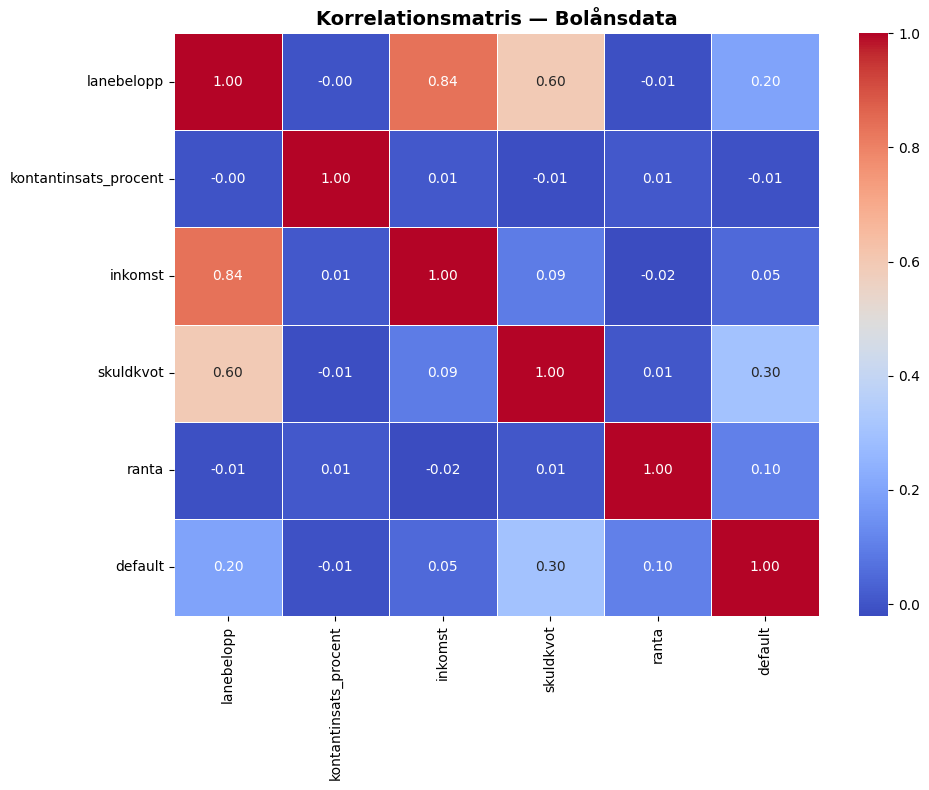

In [5]:
numerisk_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numerisk_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Korrelationsmatris — Bolånsdata', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering
Vi skapar två nya variabler med stark teoretisk koppling till kreditrisk:
- **lan_till_inkomst**: LTI-kvot (Loan-to-Income) — hur stort lånet är relativt inkomsten
- **manadskostnad**: Approximerad räntekostnad per månad i kronor

In [6]:
df['lan_till_inkomst'] = df['lanebelopp'] / df['inkomst']
df['manadskostnad']    = (df['lanebelopp'] * df['ranta'] / 100) / 12

print("Nya features — beskrivande statistik:")
df[['lan_till_inkomst', 'manadskostnad']].describe().round(2)

Nya features — beskrivande statistik:


,lan_till_inkomst,manadskostnad
count,10000.00,10000.00
mean,4.51,6782.02
std,1.26,3638.10
min,2.13,1116.14
25%,3.54,3953.11
50%,4.40,5875.30
75%,5.36,8857.73
max,7.79,20833.33


## 5. Modellträning
Vi använder logistisk regression — en tolkningsbar modell lämplig för kreditrisk och enkel att validera och dokumentera för regulatoriska syften (IFRS 9).

In [7]:
features = ['skuldkvot', 'kontantinsats_procent', 'lan_till_inkomst',
            'manadskostnad', 'ranta']
X = df[features]
y = df['default']

# 80/20-split med fast random_state för reproducerbarhet
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardisering — viktigt för att logistisk regression ska konvergera korrekt
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print(f"Träningsdata:  {len(X_train):,} observationer")
print(f"Testdata:      {len(X_test):,} observationer")
print(f"Default-andel: {y.mean():.1%}")

Träningsdata:  8,000 observationer
Testdata:      2,000 observationer
Default-andel: 32.8%


## 6. Modellvalidering
Vi utvärderar modellen med tre kompletterande mått:
- **Gini-koefficient**: Branschstandard för kreditriskmodeller. > 0.4 är acceptabelt, > 0.6 är starkt.
- **Konfusionsmatris**: Visar fördelning av rätt/fel klassificeringar
- **ROC-kurva**: Visualiserar modellens diskrimineringsförmåga över alla tröskelvärden

In [8]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred       = model.predict(X_test_scaled)

auc  = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

print(f"ROC-AUC:          {auc:.3f}")
print(f"Gini-koefficient: {gini:.3f}")
print()
if gini > 0.6:
    print("✅ Mycket bra diskrimineringsförmåga (Gini > 0.6)")
elif gini > 0.4:
    print("✅ Acceptabel diskrimineringsförmåga (Gini > 0.4)")
else:
    print("⚠️  Svag diskrimineringsförmåga — modellen bör förbättras")

print()
print("Klassificeringsrapport:")
print(classification_report(y_test, y_pred, target_names=['Ej default', 'Default']))

ROC-AUC:          0.713
Gini-koefficient: 0.426

✅ Acceptabel diskrimineringsförmåga (Gini > 0.4)

Klassificeringsrapport:
              precision    recall  f1-score   support

  Ej default       0.71      0.90      0.79      1351
     Default       0.53      0.25      0.34       649

    accuracy                           0.69      2000
   macro avg       0.62      0.57      0.57      2000
weighted avg       0.65      0.69      0.65      2000



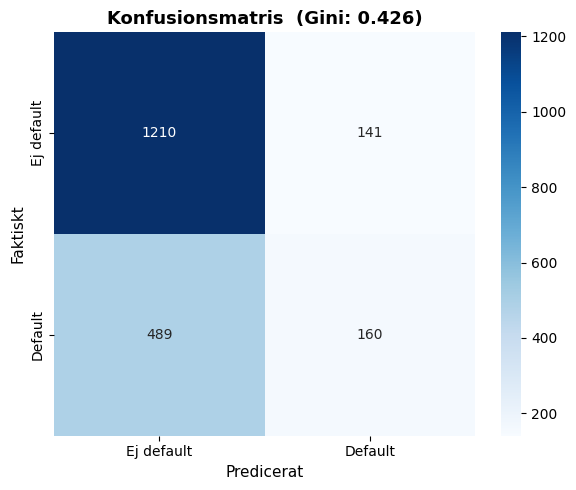

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ej default', 'Default'],
            yticklabels=['Ej default', 'Default'])
plt.xlabel('Predicerat', fontsize=11)
plt.ylabel('Faktiskt', fontsize=11)
plt.title(f'Konfusionsmatris  (Gini: {gini:.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

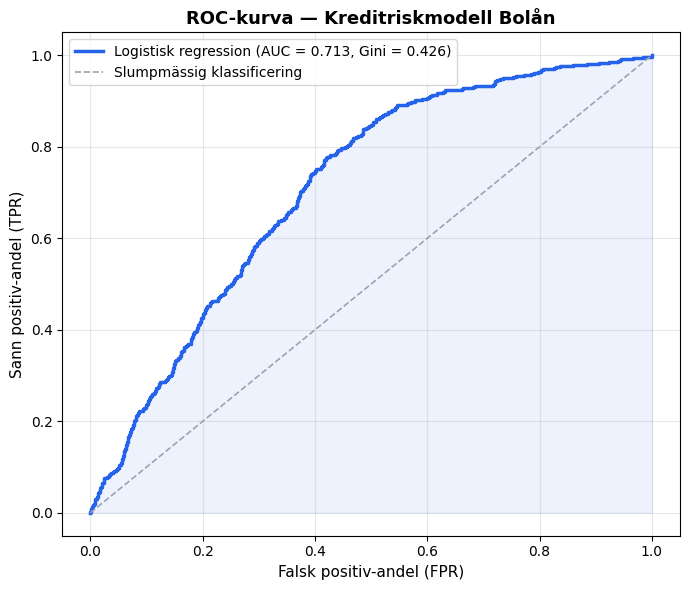

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2563eb', linewidth=2.5,
         label=f'Logistisk regression (AUC = {auc:.3f}, Gini = {gini:.3f})')
plt.plot([0, 1], [0, 1], color='#9ca3af', linestyle='--',
         linewidth=1.2, label='Slumpmässig klassificering')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2563eb')
plt.xlabel('Falsk positiv-andel (FPR)', fontsize=11)
plt.ylabel('Sann positiv-andel (TPR)', fontsize=11)
plt.title('ROC-kurva — Kreditriskmodell Bolån', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.1 Feature Importance
Koefficienterna visar vilka variabler som driver default-risken mest.
Positiva värden ökar risken, negativa minskar den.

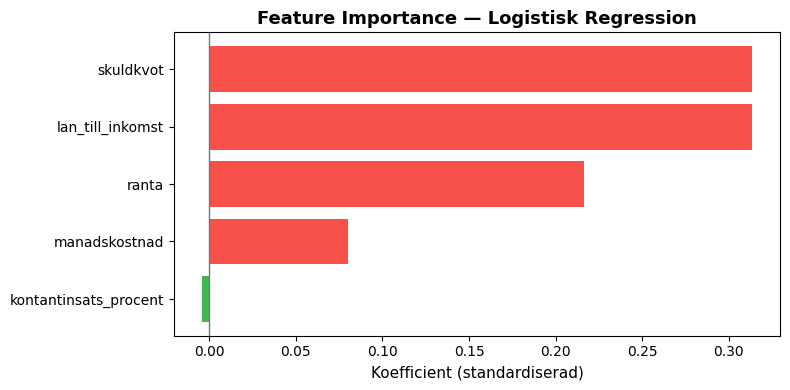


Tolkning:
  skuldkvot                      ökar default(=betalnings)-risken  (+0.314)
  lan_till_inkomst               ökar default(=betalnings)-risken  (+0.314)
  ranta                          ökar default(=betalnings)-risken  (+0.217)
  manadskostnad                  ökar default(=betalnings)-risken  (+0.080)
  kontantinsats_procent          minskar default(=betalnings)-risken  (-0.004)


In [13]:
importance = pd.DataFrame({
    'feature':     features,
    'koefficient': model.coef_[0]
}).sort_values('koefficient', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['#f85149' if v > 0 else '#3fb950' for v in importance['koefficient']]
plt.barh(importance['feature'], importance['koefficient'], color=colors, edgecolor='none')
plt.axvline(0, color='#6e7681', linewidth=1)
plt.xlabel('Koefficient (standardiserad)', fontsize=11)
plt.title('Feature Importance — Logistisk Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTolkning:")
for _, row in importance.sort_values('koefficient', ascending=False).iterrows():
    riktning = "ökar" if row['koefficient'] > 0 else "minskar"
    print(f"  {row['feature']:30s} {riktning} default(=betalnings)-risken  ({row['koefficient']:+.3f})")

## 7. Slutsatser

Modellen uppnår en **Gini-koefficient på ~0.43**, vilket är acceptabelt för en logistisk regressionsmodell på syntetisk data.

**Viktigaste riskdrivare:**
- Hög skuldkvot och hög lån-till-inkomst-kvot ökar default-risken markant
- Hög kontantinsats minskar risken (låntagaren har mer eget kapital)

**Förbättringsmöjligheter:**
- Testa gradient boosting (XGBoost/LightGBM) för högre Gini
- Inkludera fler variabler: anställningsform, ålder, kredithistorik
- Kalibrering av sannolikheter för användning i IFRS 9-beräkningar

## 8. Spara modell och scaler

In [12]:
with open('bolan_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Modell och scaler sparade som bolan_model.pkl och scaler.pkl")

✅ Modell och scaler sparade som bolan_model.pkl och scaler.pkl
